# Figure2_3

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure2")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import scipy.io as scio
import numpy as np
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM, unpack_cell
from functions.utils import first_trial_accuracy, first_trials_by_image
from functions.plotting import set_paper_theme

set_paper_theme()


### Combine Plot

In [3]:

P,SE = [],[]

# Cartoon
task = "animate_vs_inanimate_cartoon"
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM(task,monkey)
    trials_control = [tr for tr in trials if tr["img_url"].split("/")[-3].endswith("cartoon")]
    p,se,_ = first_trial_accuracy(trials_control)
    P.append(p)
    SE.append(se)

# Silhouette
task = "animate_vs_inanimate_silhouette"
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM(task,monkey)
    trials_control = [tr for tr in trials if tr["img_url"].split("/")[-3].endswith("silhouette")]
    p,se,_ = first_trial_accuracy(trials_control)
    P.append(p)
    SE.append(se)

# No leg
task = "Large_animate_vs_inanimate"
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM(task,monkey)
    trials_stim,_ = first_trials_by_image([tr for tr in trials if tr["trial_type"]=="gen"])
    label_file = scio.loadmat("data_behavior/labels_leg.mat")
    imname = unpack_cell(label_file["imgname"])
    label = unpack_cell(label_file["label"])
    noleg_img = imname[label==0]
    trials_control = [trial for trial in trials_stim if trial["img_url"].split("/")[-1] in noleg_img]
    p,se,_ = first_trial_accuracy(trials_control)
    P.append(p)
    SE.append(se)

# Pixelated
task = "Large_mammal_vs_nonmammal_pixelate"
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM(task,monkey)
    trials_stim,_ = first_trials_by_image([tr for tr in trials if tr["trial_type"]=="gen"])
    p,se,_ = first_trial_accuracy(trials_stim)
    P.append(p)
    SE.append(se)

# Grayscale
task = "Large_natural_vs_artificial_gray"
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM(task,monkey)
    trials_stim,_ = first_trials_by_image([tr for tr in trials if tr["trial_type"]=="gen"])
    p,se,_ = first_trial_accuracy(trials_stim)
    P.append(p)
    SE.append(se)


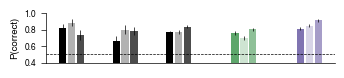

In [4]:
fig,ax = plt.subplots()
fig.set(figwidth=250/75,figheight=50/75)

barwidth=0.15
offset = 0.1
# Five control conditions, three monkeys per condition.
condition_centers = [1.1, 2.0, 2.9, 4.0, 5.1]
X = [center + displacement for center in condition_centers
     for displacement in [-barwidth, 0, barwidth]]
condition_colors = ["black", "black", "black", "#5EA66B", "#8074B1"]
Color = [(color, alpha) for color in condition_colors for alpha in [1, 0.3, 0.7]]
assert len(X) == len(P) == len(SE) == 15
ax.bar(X,P,width=barwidth-0.03,yerr=SE,color=Color,error_kw={"linewidth":0.5})
ax.axhline(0.5,linewidth=0.5,linestyle="--",color="black")
ax.set_ylabel("P(correct)")
ax.set_xticks([])
ax.set_yticks([0.4,0.6,0.8,1])
ax.set_ylim([0.4,1])

plt.savefig(FIGURE_OUTPUT_DIR / f"control_image_generalization.pdf")
plt.show()